In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from warnings import filterwarnings
filterwarnings('ignore')

In [6]:
batch_size = 32 #Maximum 32 images in a single batch
image_size = 256 #all images are resized into 256 * 256 pixels unique size

dataset = keras.preprocessing.image_dataset_from_directory(
    directory = 'dataset',
    batch_size = batch_size,
    image_size = (image_size,image_size),
    shuffle = True
)
#found 2152 files belonging to 3 classes

Found 2152 files belonging to 3 classes.


In [ ]:
#target labels
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [9]:
len(dataset)
#len of batched potato

68

In [10]:
#spiltting the dataset into training (80%) , validation (10%) , and testing (10%) sets

def train_validation_test_split(
        dataset,
        train_size = 0.8,
        validation_size=0.1,
        test_size = 0.1,
        shuffle = True,
        shuffle_size = 10000
):
    dataset_batch_count = len(dataset)
    train_batch_count = int(dataset_batch_count * train_size)
    validation_test_batch_count = int(dataset_batch_count * validation_size)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_size)
    train_ds = dataset.take(train_batch_count)
    validation_ds = dataset.skip(train_batch_count).take(validation_test_batch_count)   # Remaining 19 Batches ---> Next 9 Batch are Validation_Dataset
    test_ds = dataset.skip(train_batch_count).skip(validation_test_batch_count)         # Pending 10 Batches are Testing
    return train_ds, validation_ds, test_ds
     


In [11]:
# Apply the Function in Potato Dataset
train_ds, validation_ds, test_ds = train_validation_test_split(dataset)
len(train_ds), len(validation_ds), len(test_ds)

(54, 6, 8)

(256, 256, 3)
[[[177. 176. 184.]
  [183. 182. 190.]
  [190. 189. 197.]
  ...
  [167. 164. 173.]
  [166. 163. 172.]
  [155. 152. 161.]]

 [[182. 181. 189.]
  [184. 183. 191.]
  [185. 184. 192.]
  ...
  [159. 156. 165.]
  [157. 154. 163.]
  [146. 143. 152.]]

 [[177. 176. 184.]
  [175. 174. 182.]
  [172. 171. 179.]
  ...
  [158. 155. 164.]
  [157. 154. 163.]
  [149. 146. 155.]]

 ...

 [[196. 193. 200.]
  [195. 192. 199.]
  [195. 192. 199.]
  ...
  [145. 142. 149.]
  [148. 145. 152.]
  [150. 147. 154.]]

 [[198. 195. 202.]
  [193. 190. 197.]
  [190. 187. 194.]
  ...
  [148. 145. 152.]
  [146. 143. 150.]
  [142. 139. 146.]]

 [[198. 195. 202.]
  [190. 187. 194.]
  [184. 181. 188.]
  ...
  [152. 149. 156.]
  [149. 146. 153.]
  [140. 137. 144.]]]

(32,)
0



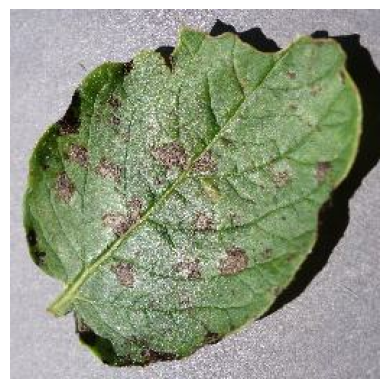

In [12]:
# Visualize the Image and Label Batches from TensorFlow Dataset

for image_batch, label_batch in train_ds.take(1):
    print(image_batch.numpy()[0].shape)
    print(image_batch.numpy()[0])
    print()

    print(label_batch.numpy().shape)
    print(label_batch.numpy()[0])
    print()

    plt.imshow(image_batch.numpy()[0].astype('uint8'))
    plt.axis('off')

In [13]:
train_ds

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [14]:
train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)
#.cache -- stroes the dataset in memory after the first load
#without cache -- tensfor flow would realod images from disk each epoch
#prefetch -- can youse multiple cpu threads

In [16]:
#building the data augmentation pipeline
#data augmentation is a form of regularization,
#it help prevent overfitting by making your model see slighlty different versions of the same image each epoch/
augmentation_pipeline = keras.Sequential([
    #makes sure all the images are the same size4
    #converts a 512 * 384 size into 256 * 256
    keras.layers.Resizing(height = image_size,width=image_size),
    #normalizing pixel values into -- [0,1]
    keras.layers.Rescaling(scale=1./255),
    #Randomly flips images horizontly and veritically
    keras.layers.RandomFlip(mode='horizontal_and_vertical'),
    #randomly rotates the image +- 20%%
    keras.layers.RandomRotation(factor=0.2),
])

#### Model Building and training

In [17]:
channel = 3
target = 3
input_shape = (batch_size,image_size,image_size,channel)
input_shape

(32, 256, 256, 3)

In [18]:
model = keras.Sequential([

            # Preprocessing Layer
            augmentation_pipeline,

            # 1st Conv Layer
            keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # 2nd Conv Layer
            keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # 3rd Conv Layer
            keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # 4th Conv Layer
            keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # 5th Conv Layer
            keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # 6th Conv Layer
            keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
            keras.layers.MaxPooling2D(pool_size=(2, 2)),

            # Flatten to 1-Dimentional Vector
            keras.layers.Flatten(),

            # Fully Connected Dense Layer
            keras.layers.Dense(units=64, activation='relu'),

            # Output Layer
            keras.layers.Dense(units=target, activation='softmax')
        ])
model

c:\Users\satya\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential_1, built=False>

In [19]:
# Display the Model Summary

model.build(input_shape)
model.summary()
     

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:

# Compiling the Model with Optimizer, Loss, and Metrics

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model

<Sequential name=sequential_1, built=True>

In [21]:
history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=35,
                    verbose=1,
                    validation_data = validation_ds)
history
     


Epoch 1/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5133 - loss: 0.9200 - val_accuracy: 0.4740 - val_loss: 0.8294
Epoch 2/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5648 - loss: 0.8374 - val_accuracy: 0.8125 - val_loss: 0.4518
Epoch 3/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7831 - loss: 0.5519 - val_accuracy: 0.7448 - val_loss: 0.5681
Epoch 4/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 992ms/step - accuracy: 0.8066 - loss: 0.4472 - val_accuracy: 0.8021 - val_loss: 0.4562
Epoch 5/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8706 - loss: 0.3230 - val_accuracy: 0.7083 - val_loss: 0.8575
Epoch 6/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8678 - loss: 0.3266 - val_accuracy: 0.8274 - val_loss: 0.4369
Epoch 7/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9227 - loss: 0.2218 - val_accuracy: 0.8036 - val_loss: 0.5393
Epoch 8/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9397 - loss: 0.1529 - val_accuracy: 0.9583 - val_lo

In [ ]:
# Accessing Training History Parameters
history.params
     

{'verbose': 1, 'epochs': 35, 'steps': 54}

In [23]:

# Accessing Keys of Training History
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [24]:
# Extracting Accuracy Metrics from Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Extracting Loss Metrics from Training History
loss = history.history['loss']
val_loss = history.history['val_loss']

In [25]:
acc[0:5]

[0.5111502408981323,
 0.6150234937667847,
 0.7857981324195862,
 0.8139671087265015,
 0.8732394576072693]

In [26]:
len(acc), len(val_acc), len(loss), len(val_loss)

(35, 35, 35, 35)

In [36]:
model.save('model.keras')

Text(0.5, 1.0, 'Training vs Validation Loss')

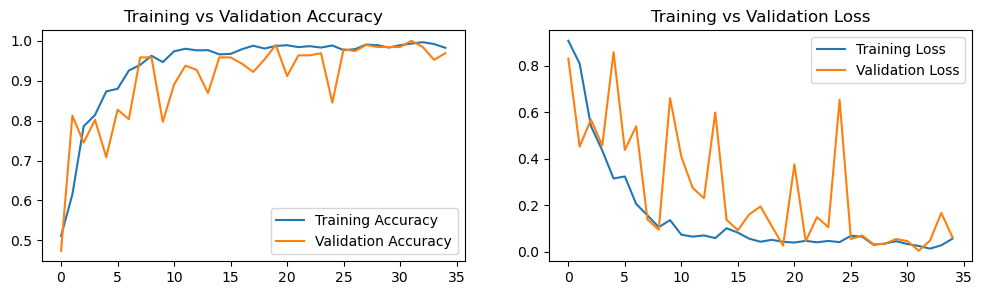

In [28]:

plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(len(loss)), loss, label='Training Loss')
plt.plot(range(len(val_loss)), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

In [29]:


class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [30]:
def prediction(image_path, class_names = dataset.class_names):

    # Read and Resize the Image using OpenCV
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))

    # Read and Resize the Image using Pillow
    # img = Image.open(image_path).resize((image_size,image_size))

    img_array = tf.keras.preprocessing.image.img_to_array(img)  # Converting Image to Array using TensorFlow
    img_array = np.expand_dims(img_array, axis=0)               # Expanding Image Array to Include Batch Dimension: (256, 256, 3) to (1, 256, 256, 3)

    model = tf.keras.models.load_model('/content/model.h5')     # Load the Trained TensorFlow Model
    prediction = model.predict(img_array)                       # Predict the Index of Class_Label

    predicted_class = class_names[np.argmax(prediction)]        # Find out the Class_Label_Name from Prediction_Dict (Using Max Probability Index)
    confidence = round(np.max(prediction)*100, 2)               # Calculate the Model Confidence

    print(f'Predicted Class : {predicted_class}')
    print(f'Confident : {confidence}%')
    print('')
    plt.imshow(img)
    plt.axis('off')